# PyTorch 신경망으로 콘크리트 강도 예측

구성:
1. 데이터 업로드 및 읽기
2. Min-Max 정규화
3. 훈련/테스트 데이터 분리
4. 하이퍼파라미터 별 모델 학습
5. 예측값과 실제값의 비교

In [17]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from itertools import product

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 장치:', device)

사용 장치: cuda


In [2]:
CSV_PATH = '../concrete_stg.csv'
if not os.path.exists(CSV_PATH):
    raise('../concrete_stg.csv 파일을 업로드하세요.')

concrete_stg = pd.read_csv(CSV_PATH)
display(concrete_stg.head())
concrete_stg.info()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [3]:
display(concrete_stg.describe())

feature_cols = ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']
target_col = 'strength'

required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in concrete_stg.columns]
if missing_cols:
    raise ValueError(f'CSV 파일에 다음 열이 없습니다: {missing_cols}')

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [4]:
def min_max_normalize(series):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(np.zeros(len(series)), index=series.index)

    return (series - min_value) / (max_value - min_value)

concrete_stg_norm = concrete_stg.apply(min_max_normalize)

print('정규화된 strength 통계량')
display(concrete_stg_norm[target_col].describe())

print('원본 strength 통계량')
display(concrete_stg[target_col].describe())
display(concrete_stg_norm.describe())

정규화된 strength 통계량


count    1030.000000
mean        0.417191
std         0.208119
min         0.000000
25%         0.266351
50%         0.400087
75%         0.545721
max         1.000000
Name: strength, dtype: float64

원본 strength 통계량


count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: strength, dtype: float64

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,0.409059,0.205609,0.270806,0.477374,0.192691,0.499764,0.450528,0.122698,0.417191
std,0.238599,0.240065,0.319825,0.170561,0.185523,0.226029,0.201144,0.173544,0.208119
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.206336,0.000000,0.000000,0.344249,0.000000,0.380814,0.343578,0.016484,0.266351
50%,0.390183,0.061213,0.000000,0.504792,0.198758,0.485465,0.465379,0.074176,0.400087
75%,0.566210,0.397746,0.591204,0.560703,0.316770,0.663953,0.577020,0.151099,0.545721
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
train_df = concrete_stg_norm.iloc[:780].copy()
test_df = concrete_stg_norm.iloc[780:1030].copy()

X_train_np = train_df[feature_cols].values.astype(np.float32)
y_train_np = train_df[target_col].values.astype(np.float32).reshape(-1, 1)

X_test_np = test_df[feature_cols].values.astype(np.float32)
y_test_np = test_df[target_col].values.astype(np.float32).reshape(-1, 1)

X_train = torch.tensor(X_train_np).to(device)
y_train = torch.tensor(y_train_np).to(device)

X_test = torch.tensor(X_test_np).to(device)
y_test = torch.tensor(y_test_np).to(device)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: torch.Size([780, 8])
y_train: torch.Size([780, 1])
X_test: torch.Size([250, 8])
y_test: torch.Size([250, 1])


In [22]:
class ConcreteANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='sigmoid', 
                 use_drop_out: bool = False, drop_out_raito: float = 0.1,
                 use_batch_norm: bool = False
                ):
        super().__init__()

        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())

            elif activation == 'softplus':
                layers.append(nn.Softplus())

            elif activation == 'tanh':
                layers.append(nn.Tanh())
                
            elif activation == 'relu':
                layers.append(nn.ReLU())

            else:
                raise ValueError('사용할 수 없는 activation function 입니다.')

            if use_drop_out:
                layers.append(nn.Dropout(drop_out_raito))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [7]:
def train_model(model, X_train, y_train, epochs=5000, lr=0.01, print_every=500):
    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(1, epochs + 1):
        model.train()

        optimizer.zero_grad()

        y_pred = model(X_train)

        loss = criterion(y_pred, y_train)

        loss.backward()

        optimizer.step()

        loss_history.append(loss.item())

        if epoch % print_every == 0 or epoch == 1:
            print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f}')

    return model, loss_history

def evaluate_model(model, X_test, y_test):
    model.eval()

    with torch.no_grad():
        pred = model(X_test)

        mse = nn.MSELoss()(pred, y_test).item()

    pred_np = pred.cpu().numpy().reshape(-1)

    true_np = y_test.cpu().numpy().reshape(-1)

    corr = np.corrcoef(pred_np, true_np)[0, 1]

    return pred_np, corr, mse

def plot_loss(loss_history, title):
    plt.figure(figsize=(8, 4))

    plt.plot(loss_history)

    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')

    plt.grid(True)

    plt.show()

In [8]:
input_dim = len(feature_cols)

# experiment condition
epochs_list = [5000, 8000, 10000]
lr_list = [0.01, 0.001, 0.003]
hidden_layers_list = [
    [5],
    [5, 5],
    [5, 3, 2]
]
activation_list = [
    'sigmoid',
    'softplus',
    'tanh',
    'relu'
]

results = []
pred_list = []

exp_num = 1

for epochs, lr, hidden_layers, activation in product(
    epochs_list,
    lr_list,
    hidden_layers_list,
    activation_list
):

    print(
        f"\n===== 실험 {exp_num} 시작 =====\n"
        f"Epoch={epochs}, "
        f"LR={lr}, "
        f"Hidden={hidden_layers}, "
        f"Activation={activation}"
    )

    # Create Model
    model = ConcreteANN(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        activation=activation
    )

    # Train phase
    model, loss = train_model(
        model,
        X_train,
        y_train,
        epochs=epochs,
        lr=lr,
        print_every=1000
    )

    # Test phase
    pred, corr, mse = evaluate_model(
        model,
        X_test,
        y_test
    )

    # Save experiment logs and evaluation metrics
    results.append({
        "실험번호": f"실험{exp_num}",
        "Epoch": epochs,
        "Learning Rate": lr,
        "Hidden Node": str(hidden_layers),
        "Activation": activation,
        "MSE": mse,
        "Correlation": corr
    })
    pred_list.append(pred)

    print(f"Correlation : {corr:.4f}")
    print(f"MSE         : {mse:.6f}")

    exp_num += 1

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="MSE",
    ascending=True
).reset_index(drop=True)

print(results_df)
print(results_df.to_markdown(index=False))


===== 실험 1 시작 =====
Epoch=5000, LR=0.01, Hidden=[5], Activation=sigmoid
Epoch     1 | Loss: 0.146147
Epoch  1000 | Loss: 0.008336
Epoch  2000 | Loss: 0.006088
Epoch  3000 | Loss: 0.005313
Epoch  4000 | Loss: 0.004864
Epoch  5000 | Loss: 0.004605
Correlation : 0.9244
MSE         : 0.005999

===== 실험 2 시작 =====
Epoch=5000, LR=0.01, Hidden=[5], Activation=softplus
Epoch     1 | Loss: 0.238165
Epoch  1000 | Loss: 0.009331
Epoch  2000 | Loss: 0.007732
Epoch  3000 | Loss: 0.006682
Epoch  4000 | Loss: 0.006341
Epoch  5000 | Loss: 0.006139
Correlation : 0.9053
MSE         : 0.007431

===== 실험 3 시작 =====
Epoch=5000, LR=0.01, Hidden=[5], Activation=tanh
Epoch     1 | Loss: 0.106963
Epoch  1000 | Loss: 0.007051
Epoch  2000 | Loss: 0.005407
Epoch  3000 | Loss: 0.004999
Epoch  4000 | Loss: 0.004800
Epoch  5000 | Loss: 0.004527
Correlation : 0.9292
MSE         : 0.005628

===== 실험 4 시작 =====
Epoch=5000, LR=0.01, Hidden=[5], Activation=relu
Epoch     1 | Loss: 0.224136
Epoch  1000 | Loss: 0.015448
E

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlation : nan
MSE         : 0.041160

===== 실험 13 시작 =====
Epoch=5000, LR=0.001, Hidden=[5], Activation=sigmoid
Epoch     1 | Loss: 0.359497
Epoch  1000 | Loss: 0.028229
Epoch  2000 | Loss: 0.017336
Epoch  3000 | Loss: 0.016003
Epoch  4000 | Loss: 0.014658
Epoch  5000 | Loss: 0.012116
Correlation : 0.8088
MSE         : 0.014365

===== 실험 14 시작 =====
Epoch=5000, LR=0.001, Hidden=[5], Activation=softplus
Epoch     1 | Loss: 0.065616
Epoch  1000 | Loss: 0.016260
Epoch  2000 | Loss: 0.013747
Epoch  3000 | Loss: 0.009772
Epoch  4000 | Loss: 0.008688
Epoch  5000 | Loss: 0.007750
Correlation : 0.8742
MSE         : 0.009730

===== 실험 15 시작 =====
Epoch=5000, LR=0.001, Hidden=[5], Activation=tanh
Epoch     1 | Loss: 0.621419
Epoch  1000 | Loss: 0.018713
Epoch  2000 | Loss: 0.014498
Epoch  3000 | Loss: 0.011808
Epoch  4000 | Loss: 0.009435
Epoch  5000 | Loss: 0.008431
Correlation : 0.8638
MSE         : 0.010501

===== 실험 16 시작 =====
Epoch=5000, LR=0.001, Hidden=[5], Activation=relu
Epoch     

In [9]:
results_df = results_df.sort_values(
    by="Correlation",
    ascending=False
)

print(results_df)
print(results_df.to_markdown(index=False))

      실험번호  Epoch  Learning Rate Hidden Node Activation       MSE  Correlation
0      실험7   5000          0.010      [5, 5]       tanh  0.004892     0.938770
1     실험43   8000          0.010      [5, 5]       tanh  0.004925     0.938509
3     실험77  10000          0.010      [5, 5]    sigmoid  0.004962     0.938269
4     실험81  10000          0.010   [5, 3, 2]    sigmoid  0.004980     0.938142
2    실험107  10000          0.003   [5, 3, 2]       tanh  0.004938     0.938038
..     ...    ...            ...         ...        ...       ...          ...
103   실험24   5000          0.001   [5, 3, 2]       relu  0.041160          NaN
104   실험36   5000          0.003   [5, 3, 2]       relu  0.041160          NaN
105   실험48   8000          0.010   [5, 3, 2]       relu  0.041160          NaN
106   실험12   5000          0.010   [5, 3, 2]       relu  0.041160          NaN
107   실험96  10000          0.001   [5, 3, 2]       relu  0.041160          NaN

[108 rows x 7 columns]
| 실험번호   |   Epoch |   Learn

In [10]:
best_df = results_df.loc[
    results_df.groupby('Activation')['MSE'].idxmin()
]
print(best_df.to_markdown(index=False))

| 실험번호   |   Epoch |   Learning Rate | Hidden Node   | Activation   |        MSE |   Correlation |
|:-----------|--------:|----------------:|:--------------|:-------------|-----------:|--------------:|
| 실험80     |   10000 |            0.01 | [5, 5]        | relu         | 0.00638154 |      0.920698 |
| 실험77     |   10000 |            0.01 | [5, 5]        | sigmoid      | 0.00496159 |      0.938269 |
| 실험42     |    8000 |            0.01 | [5, 5]        | softplus     | 0.00529839 |      0.933457 |
| 실험7      |    5000 |            0.01 | [5, 5]        | tanh         | 0.00489233 |      0.93877  |


In [11]:
input_dim = len(feature_cols)

results2 = []
pred_list_2 = []

exp_num = 1
for hidden_layers in [[10,10], [20,20],[50,50]]:
    # Create Model
    model = ConcreteANN(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        activation='tanh'
    )

    # Train phase
    model, loss = train_model(
        model,
        X_train,
        y_train,
        epochs=5000,
        lr=lr,
        print_every=1000
    )

    # Test phase
    pred, corr, mse = evaluate_model(
        model,
        X_test,
        y_test
    )

    # Save experiment logs and evaluation metrics
    results2.append({
        "실험번호": f"실험{exp_num}",
        "Hidden Node": str(hidden_layers),
        "MSE": mse,
        "Correlation": corr
    })
    pred_list_2.append(pred)

    print(f"Correlation : {corr:.4f}")
    print(f"MSE         : {mse:.6f}")

    exp_num += 1

Epoch     1 | Loss: 0.349859
Epoch  1000 | Loss: 0.007344
Epoch  2000 | Loss: 0.005757
Epoch  3000 | Loss: 0.004722
Epoch  4000 | Loss: 0.004026
Epoch  5000 | Loss: 0.003645
Correlation : 0.9371
MSE         : 0.005044
Epoch     1 | Loss: 0.326574
Epoch  1000 | Loss: 0.006738
Epoch  2000 | Loss: 0.004725
Epoch  3000 | Loss: 0.004052
Epoch  4000 | Loss: 0.003550
Epoch  5000 | Loss: 0.003289
Correlation : 0.9416
MSE         : 0.004964
Epoch     1 | Loss: 0.113724
Epoch  1000 | Loss: 0.004522
Epoch  2000 | Loss: 0.003227
Epoch  3000 | Loss: 0.002661
Epoch  4000 | Loss: 0.002059
Epoch  5000 | Loss: 0.001572
Correlation : 0.9456
MSE         : 0.004441


In [12]:
results_df2 = pd.DataFrame(results2)

results_df2 = results_df2.sort_values(
    by="MSE",
    ascending=True
).reset_index(drop=True)

print(results_df2)
print(results_df2.to_markdown(index=False))

  실험번호 Hidden Node       MSE  Correlation
0  실험3    [50, 50]  0.004441     0.945617
1  실험2    [20, 20]  0.004964     0.941632
2  실험1    [10, 10]  0.005044     0.937051
| 실험번호   | Hidden Node   |        MSE |   Correlation |
|:-----------|:--------------|-----------:|--------------:|
| 실험3      | [50, 50]      | 0.00444133 |      0.945617 |
| 실험2      | [20, 20]      | 0.00496357 |      0.941632 |
| 실험1      | [10, 10]      | 0.00504407 |      0.937051 |


In [14]:
print(pd.DataFrame(results2).to_markdown(index=False))

| 실험번호   | Hidden Node   |        MSE |   Correlation |
|:-----------|:--------------|-----------:|--------------:|
| 실험1      | [10, 10]      | 0.00504407 |      0.937051 |
| 실험2      | [20, 20]      | 0.00496357 |      0.941632 |
| 실험3      | [50, 50]      | 0.00444133 |      0.945617 |


In [20]:
input_dim = len(feature_cols)

results3 = []
pred_list_3 = []

exp_num = 1
for hidden_layers in [[10,10], [20,20],[50,50]]:
    # Create Model
    model = ConcreteANN(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        activation='tanh',
        use_drop_out=True,
        drop_out_raito=0.1
    )

    # Train phase
    model, loss = train_model(
        model,
        X_train,
        y_train,
        epochs=5000,
        lr=lr,
        print_every=1000
    )

    # Test phase
    pred, corr, mse = evaluate_model(
        model,
        X_test,
        y_test
    )

    # Save experiment logs and evaluation metrics
    results3.append({
        "실험번호": f"실험{exp_num}",
        "Hidden Node": str(hidden_layers),
        "MSE": mse,
        "Correlation": corr
    })
    pred_list_3.append(pred)

    print(f"Correlation : {corr:.4f}")
    print(f"MSE         : {mse:.6f}")

    exp_num += 1

print(pd.DataFrame(results3).to_markdown(index=False))

Epoch     1 | Loss: 0.148536
Epoch  1000 | Loss: 0.009371
Epoch  2000 | Loss: 0.008753
Epoch  3000 | Loss: 0.008067
Epoch  4000 | Loss: 0.007825
Epoch  5000 | Loss: 0.007607
Correlation : 0.9086
MSE         : 0.007174
Epoch     1 | Loss: 0.147426
Epoch  1000 | Loss: 0.008143
Epoch  2000 | Loss: 0.007240
Epoch  3000 | Loss: 0.006882
Epoch  4000 | Loss: 0.006554
Epoch  5000 | Loss: 0.006083
Correlation : 0.9184
MSE         : 0.006465
Epoch     1 | Loss: 0.460693
Epoch  1000 | Loss: 0.008265
Epoch  2000 | Loss: 0.007195
Epoch  3000 | Loss: 0.005835
Epoch  4000 | Loss: 0.005485
Epoch  5000 | Loss: 0.005083
Correlation : 0.9325
MSE         : 0.005372
| 실험번호   | Hidden Node   |        MSE |   Correlation |
|:-----------|:--------------|-----------:|--------------:|
| 실험1      | [10, 10]      | 0.00717385 |      0.908617 |
| 실험2      | [20, 20]      | 0.00646489 |      0.91843  |
| 실험3      | [50, 50]      | 0.00537196 |      0.932468 |


In [24]:
input_dim = len(feature_cols)

results4 = []
pred_list_4 = []
loss_list_4 = []

exp_num = 1
for hidden_layers in [[10,10], [20,20],[50,50]]:
    # Create Model
    model = ConcreteANN(
        input_dim=input_dim,
        hidden_layers=hidden_layers,
        activation='tanh',
        use_drop_out=True,
        drop_out_raito=0.1,
        use_batch_norm=True
    )

    # Train phase
    model, loss = train_model(
        model,
        X_train,
        y_train,
        epochs=5000,
        lr=lr,
        print_every=1000
    )
    loss_list_4.append(loss)

    # Test phase
    pred, corr, mse = evaluate_model(
        model,
        X_test,
        y_test
    )

    # Save experiment logs and evaluation metrics
    results4.append({
        "실험번호": f"실험{exp_num}",
        "Hidden Node": str(hidden_layers),
        "MSE": mse,
        "Correlation": corr
    })
    pred_list_4.append(pred)

    print(f"Correlation : {corr:.4f}")
    print(f"MSE         : {mse:.6f}")

    exp_num += 1

print(pd.DataFrame(results4).to_markdown(index=False))

Epoch     1 | Loss: 0.497973
Epoch  1000 | Loss: 0.009442
Epoch  2000 | Loss: 0.007449
Epoch  3000 | Loss: 0.006596
Epoch  4000 | Loss: 0.006286
Epoch  5000 | Loss: 0.006024
Correlation : 0.9304
MSE         : 0.005551
Epoch     1 | Loss: 0.642748
Epoch  1000 | Loss: 0.007967
Epoch  2000 | Loss: 0.006465
Epoch  3000 | Loss: 0.005123
Epoch  4000 | Loss: 0.004904
Epoch  5000 | Loss: 0.004466
Correlation : 0.9405
MSE         : 0.004793
Epoch     1 | Loss: 0.305522
Epoch  1000 | Loss: 0.004910
Epoch  2000 | Loss: 0.003585
Epoch  3000 | Loss: 0.002903
Epoch  4000 | Loss: 0.002276
Epoch  5000 | Loss: 0.002160
Correlation : 0.9483
MSE         : 0.004431
| 실험번호   | Hidden Node   |        MSE |   Correlation |
|:-----------|:--------------|-----------:|--------------:|
| 실험1      | [10, 10]      | 0.00555061 |      0.930419 |
| 실험2      | [20, 20]      | 0.00479311 |      0.940507 |
| 실험3      | [50, 50]      | 0.00443099 |      0.948271 |


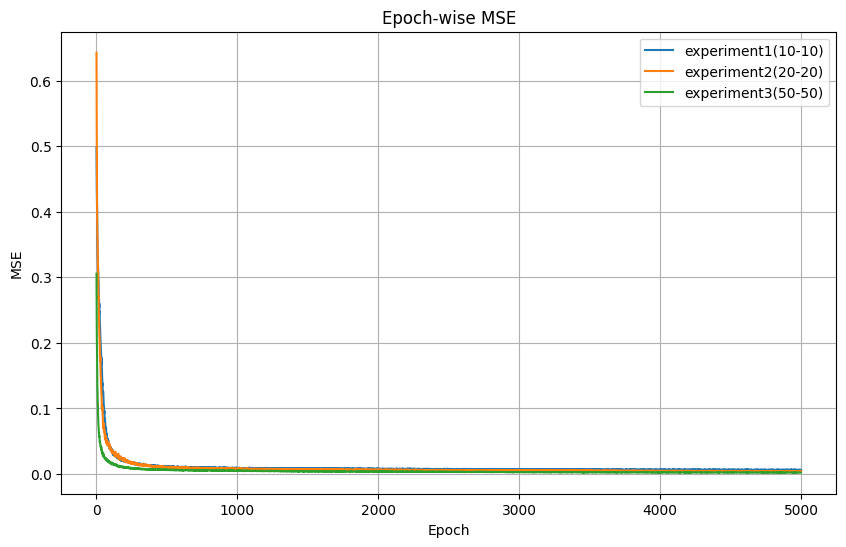

In [26]:
experiment_names = ['experiment1(10-10)', 'experiment2(20-20)', 'experiment3(50-50)']

plt.figure(figsize=(10,6))

for i, loss_list in enumerate(loss_list_4):
    plt.plot(range(1, len(loss_list)+1), loss_list, label=experiment_names[i])

plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Epoch-wise MSE')
plt.legend()
plt.grid(True)
plt.show()

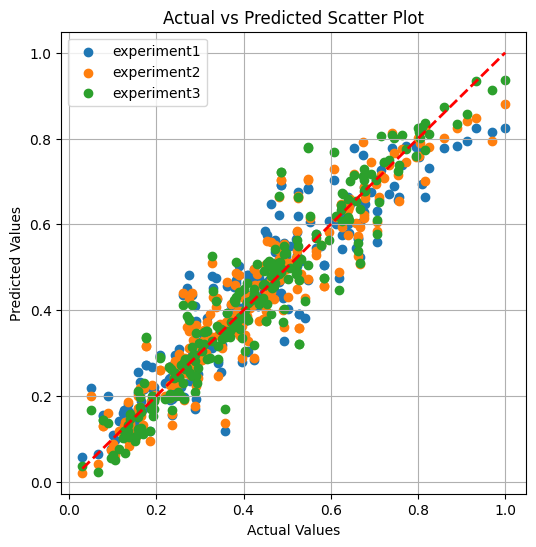

experiment1 Performance:
  MSE: 0.0056
  MAE: 0.0557
  R² Score: 0.8650

experiment2 Performance:
  MSE: 0.0048
  MAE: 0.0502
  R² Score: 0.8834

experiment3 Performance:
  MSE: 0.0044
  MAE: 0.0460
  R² Score: 0.8922



In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_test_cpu = y_test.cpu().numpy()

experiment_names = ['experiment1', 'experiment2', 'experiment3']

plt.figure(figsize=(6,6))
for i, preds in enumerate(pred_list_4):
    plt.scatter(y_test_cpu, preds, label=experiment_names[i])

plt.plot([y_test_cpu.min(), y_test_cpu.max()], [y_test_cpu.min(), y_test_cpu.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Scatter Plot')
plt.legend()
plt.grid(True)
plt.show()

for i, preds in enumerate(pred_list_4):
    mse = mean_squared_error(y_test_cpu, preds)
    mae = mean_absolute_error(y_test_cpu, preds)
    r2 = r2_score(y_test_cpu, preds)
    print(f"{experiment_names[i]} Performance:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R² Score: {r2:.4f}\n")